# Airline Data Challenge 


## Problem Statement

###  The primary objective of this analysis is to understand the operational, financial, and strategic performance of U.S. airlines during the first quarter of 2019 (1Q2019), with a focus on which 5 round-trip routes to invest in. The big idea behind the project is that route-level profitability and efficiency are deeply influenced by passenger demand, delay patterns, and fare strategies, and by uncovering these relationships, airlines can optimize operations and revenue. Our mission is to maximize profitability, minimize delays, and operate where demand is high in line with brand promise: “On time, for you.”

## Executive Summary

### In the first quarter of 2019, U.S. airlines experienced a notable decline in net profits, driven by increasing operational costs, suboptimal route utilization, and delays. This analysis examines round-trip flight data to uncover trends in fare pricing, passenger volume, delays, and route-level performance. We find that high-demand routes often show higher fares but also suffer from greater delays, likely due to air traffic congestion. Busy airports and profitable round-trip corridors show strong occupancy rates, but operational inefficiencies, especially flight delays negatively impact margins and customer satisfaction.

## Key Objectives
### Determine which routes are busiest and most profitable.
###  Identify the 10 busiest and 10 most profitable round-trip routes.

### Recommend the top 5 routes for investment, balancing profitability, frequency, and punctuality.

### Develop a scoring system using delay, profit, and flight count to rank routes.

### Calculate the breakeven point for each route  based on a 90 million plane cost.

### Recommend a focused set of KPI metrics to track operational and financial success.

## Data loading - load all the three datasets flights, airport_codes, tickets to prepare for data analysis

In [1]:
#Import Libraries
import os

# For data manipulation
import pandas as pd
import numpy as np

# For data plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_datasets(base_path):
    """
    Load the Flights, Tickets, and Airport Codes datasets.

    """
    try:
        # Load Flights
        flights = pd.read_csv(os.path.join(base_path, "Flights.csv"), low_memory=False)

        # Load Tickets
        tickets = pd.read_csv(os.path.join(base_path, "Tickets.csv"), low_memory=False)

        # Load Airport Codes
        airport_codes = pd.read_csv(os.path.join(base_path, "Airport_Codes.csv"), low_memory=False)

        print(" All datasets loaded.")
        print(f"Flights shape: {flights.shape}")
        print(f"Tickets shape: {tickets.shape}")
        print(f"Airport Codes shape: {airport_codes.shape}")

        return flights, tickets, airport_codes

    except Exception as e:
        print(f" Error loading datasets: {e}")
        return None, None, None


In [3]:
# path
base_path = "C:\CapitalOne"

flights_df, tickets_df, airport_codes_df = load_datasets(base_path)

 All datasets loaded.
Flights shape: (1915886, 16)
Tickets shape: (1167285, 12)
Airport Codes shape: (55369, 8)


## Data Quality Check 
### Analyze the data and prepare for further analysis to identifying missing values, detecting outliers or anomalies, verifying data types, checking for duplicates, and ensuring that the data adheres to defined business rules or schema constraints.

## Data Pre-processing & Exploratory Data Analysis on Flights data

### By examining the dataset, we observe detailed flight-level operational data including flight dates, carriers, aircraft IDs, origin and destination airports, delays, cancellations, flight distances, and occupancy rates. The data reflects both on-time and delayed flights, with occupancy rates varying significantly across routes, indicating differing levels of seat utilization and potential revenue efficiency. However, the presence of data quality issues, such as inconsistent date formats and invalid distance entries, duplicate values suggests that some preprocessing is necessary before analysis. Overall, the dataset provides a strong foundation for evaluating airline performance, identifying delay patterns, and assessing route profitability.

In [4]:
# Sample data

print(flights_df.head())
print(flights_df.tail())

      FL_DATE OP_CARRIER TAIL_NUM OP_CARRIER_FL_NUM  ORIGIN_AIRPORT_ID ORIGIN  \
0  2019-03-02         WN   N955WN              4591              14635    RSW   
1  2019-03-02         WN   N8686A              3231              14635    RSW   
2  2019-03-02         WN   N201LV              3383              14635    RSW   
3  2019-03-02         WN   N413WN              5498              14635    RSW   
4  2019-03-02         WN   N7832A              6933              14635    RSW   

  ORIGIN_CITY_NAME  DEST_AIRPORT_ID DESTINATION DEST_CITY_NAME  DEP_DELAY  \
0   Fort Myers, FL            11042         CLE  Cleveland, OH       -8.0   
1   Fort Myers, FL            11066         CMH   Columbus, OH        1.0   
2   Fort Myers, FL            11066         CMH   Columbus, OH        0.0   
3   Fort Myers, FL            11066         CMH   Columbus, OH       11.0   
4   Fort Myers, FL            11259         DAL     Dallas, TX        0.0   

   ARR_DELAY  CANCELLED AIR_TIME DISTANCE  OCCUPAN

In [5]:
flights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915886 entries, 0 to 1915885
Data columns (total 16 columns):
 #   Column             Dtype  
---  ------             -----  
 0   FL_DATE            object 
 1   OP_CARRIER         object 
 2   TAIL_NUM           object 
 3   OP_CARRIER_FL_NUM  object 
 4   ORIGIN_AIRPORT_ID  int64  
 5   ORIGIN             object 
 6   ORIGIN_CITY_NAME   object 
 7   DEST_AIRPORT_ID    int64  
 8   DESTINATION        object 
 9   DEST_CITY_NAME     object 
 10  DEP_DELAY          float64
 11  ARR_DELAY          float64
 12  CANCELLED          float64
 13  AIR_TIME           object 
 14  DISTANCE           object 
 15  OCCUPANCY_RATE     float64
dtypes: float64(4), int64(2), object(10)
memory usage: 233.9+ MB


In [6]:
# Data Inconsistency

flights_df['FL_DATE'].unique()

array(['2019-03-02', '2019-03-03', '2019-03-09', '2019-03-10',
       '2019-03-24', '2019-03-28', '2019-03-29', '2019-03-30',
       '2019-03-20', '2019-03-25', '2019-03-26', '2019-03-31',
       '2019-03-13', '2019-03-14', '2019-03-12', '2019-03-11',
       '2019-03-15', '2019-03-16', '2019-03-17', '2019-03-18',
       '2019-03-19', '2019-03-21', '2019-03-22', '2019-03-23',
       '2019-03-27', '2019-03-01', '2019-03-04', '2019-03-05',
       '2019-03-06', '2019-03-07', '2019-03-08', '2019-02-17',
       '2019-02-18', '2019-02-19', '2019-02-20', '2019-02-21',
       '2019-02-22', '2019-02-23', '2019-02-24', '2019-02-25',
       '2019-02-26', '2019-02-27', '2019-02-28', '2019-02-01',
       '2019-02-02', '2019-02-03', '2019-02-04', '2019-02-05',
       '2019-02-06', '2019-02-07', '2019-02-08', '2019-02-09',
       '2019-02-10', '2019-02-11', '2019-02-12', '2019-02-13',
       '2019-02-14', '2019-02-15', '2019-02-16', '2019-01-21',
       '2019-01-24', '2019-01-25', '2019-01-26', '2019-

In [7]:
# Convert FL_Date datatype to datetime datatype for easier filtering

flights_df['FL_DATE'] = pd.to_datetime(flights_df['FL_DATE'], errors='coerce')
print(flights_df['FL_DATE'].head(10))

0   2019-03-02
1   2019-03-02
2   2019-03-02
3   2019-03-02
4   2019-03-02
5   2019-03-02
6   2019-03-02
7   2019-03-02
8   2019-03-02
9   2019-03-02
Name: FL_DATE, dtype: datetime64[ns]


In [8]:
# Converts char fields to numbers to avoid non-numeric values '****' or invalid

flights_df['DISTANCE'] = pd.to_numeric(flights_df['DISTANCE'], errors='coerce')
flights_df['AIR_TIME'] = pd.to_numeric(flights_df['AIR_TIME'], errors= 'coerce')

In [9]:
# Check cancellations

print(f"Cancelled flights: {flights_df['CANCELLED'].sum()} out of {len(flights_df)}")

Cancelled flights: 51614.0 out of 1915886


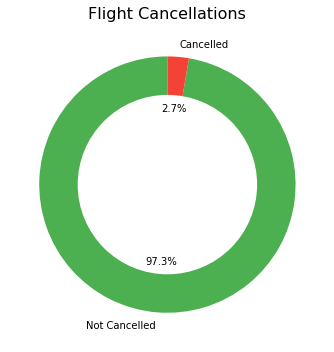

In [10]:
# Count cancelled vs not cancelled flights
cancel_counts = flights_df['CANCELLED'].value_counts()

# Labels and colors
labels = ['Not Cancelled', 'Cancelled']
colors = ['#4CAF50', '#F44336']  # Green for not cancelled, Red for cancelled

# Create donut chart
plt.figure(figsize=(5,5))
plt.pie(cancel_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

# Add a white circle in the center to make it a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Flight Cancellations", fontsize=16)
plt.tight_layout()
plt.show()


### Out of a total of 1,915,886 flight records, 51,614 flights were cancelled, representing approximately 2.7% of the dataset. While this is a relatively small portion, it is still significant in operational and financial terms. Cancelled flights disrupt schedules, lead to lost revenue, and affect passenger satisfaction and airline reliability metrics.  Since cancelled flights do not have complete operational data such as actual departure/arrival times, delays, air time, or occupancy rate, they can introduce bias or inaccuracies into the analysis. Therefore, it is essential to exclude cancelled flights from the analysis to ensure accuracy and focus on flights that were actually operated. This filtered dataset will provide a more reliable foundation for evaluating airline performance, route efficiency, and delay patterns.

In [11]:
#Exclude Cancellation Flights

flights_df = flights_df[flights_df['CANCELLED'] == 0]

# Reset the index in place
flights_df.reset_index(drop=True, inplace=True)

In [12]:
# Checking for Duplicated rows

flights_df.duplicated().sum()

4410

In [13]:
# Drop the duplicate rows
# 4410 duplicate rows are dropped

flights_df = flights_df.drop_duplicates()

In [14]:
flights_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1859862 entries, 0 to 1859861
Data columns (total 16 columns):
 #   Column             Dtype         
---  ------             -----         
 0   FL_DATE            datetime64[ns]
 1   OP_CARRIER         object        
 2   TAIL_NUM           object        
 3   OP_CARRIER_FL_NUM  object        
 4   ORIGIN_AIRPORT_ID  int64         
 5   ORIGIN             object        
 6   ORIGIN_CITY_NAME   object        
 7   DEST_AIRPORT_ID    int64         
 8   DESTINATION        object        
 9   DEST_CITY_NAME     object        
 10  DEP_DELAY          float64       
 11  ARR_DELAY          float64       
 12  CANCELLED          float64       
 13  AIR_TIME           float64       
 14  DISTANCE           float64       
 15  OCCUPANCY_RATE     float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(7)
memory usage: 241.2+ MB


In [15]:
# Unique values for key categorical columns

print("Unique ORIGIN airports:", flights_df['ORIGIN'].nunique())
print("Unique DESTINATION airports:", flights_df['DESTINATION'].nunique())

Unique ORIGIN airports: 361
Unique DESTINATION airports: 361


In [16]:
# Checking for Null-Values

flights_df.isnull().sum()

FL_DATE                 0
OP_CARRIER              0
TAIL_NUM                0
OP_CARRIER_FL_NUM       0
ORIGIN_AIRPORT_ID       0
ORIGIN                  0
ORIGIN_CITY_NAME        0
DEST_AIRPORT_ID         0
DESTINATION             0
DEST_CITY_NAME          0
DEP_DELAY               0
ARR_DELAY            4368
CANCELLED               0
AIR_TIME             4616
DISTANCE              268
OCCUPANCY_RATE         31
dtype: int64

In [17]:
def impute_with_median(flights_df, columns_to_impute):
    """
    Imputes missing values in the specified columns with the column median.

    Parameters:
    - flights_df: pandas DataFrame
    - columns_to_impute: list of column names to impute
    """
    for column in columns_to_impute:
        if column in flights_df.columns:
            median_value = flights_df[column].median()
            flights_df[column].fillna(median_value, inplace=True)

### This approach ensures that missing data is handled in a way that minimizes distortion of the data distribution, especially for numerical columns that may have outliers.

In [18]:
impute_columns = ['DEP_DELAY', 'ARR_DELAY', 'AIR_TIME', 'DISTANCE','OCCUPANCY_RATE']

impute_with_median(flights_df, impute_columns)

### Outliers

### The below visualizes the distribution of key flight-related variables using boxplots, which are effective for identifying outliers-data points that fall far outside the typical range. Outliers can occur due to data entry errors, unusual but valid events, or rare conditions. In this dataset, variables like AIR_TIME, DISTANCE, DEP_DELAY, and ARR_DELAY often have extreme values that can skew analysis and statistical modeling. So, I applied a logarithmic transformation to these columns to reduce the impact of extreme values and make the data distribution more normal-like, which helps in stabilizing variance and improving model performance. Handling outliers through visualization and transformations is critical to ensure that insights and predictions derived from the data are robust, reliable, and not disproportionately influenced by extreme cases.

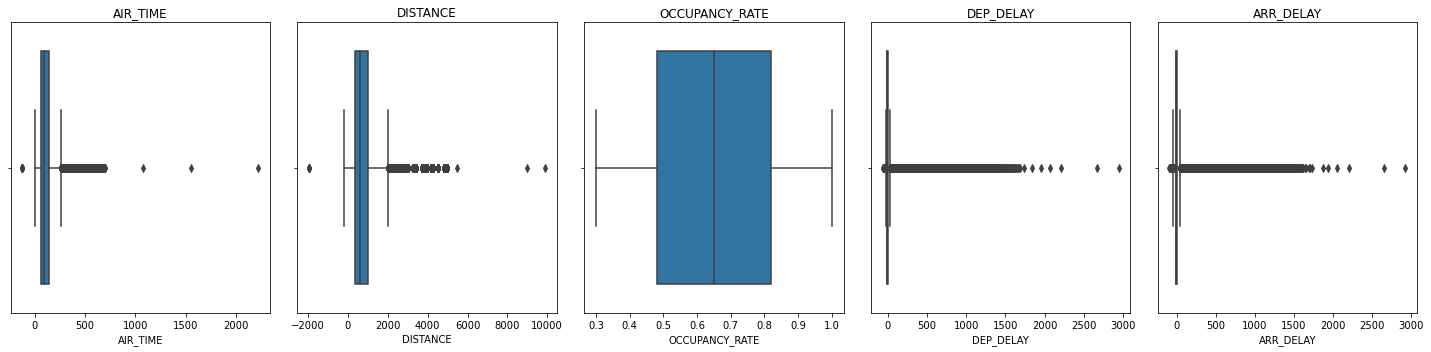

In [19]:
# Create 1 row and 5 columns of subplots
fig, ax = plt.subplots(1, 5, figsize=(20, 5))  # Adjust figsize as needed

# Plot each boxplot on its respective axis
sns.boxplot(x='AIR_TIME', data=flights_df, ax=ax[0])
ax[0].set_title('AIR_TIME')

sns.boxplot(x='DISTANCE', data=flights_df, ax=ax[1])
ax[1].set_title('DISTANCE')

sns.boxplot(x='OCCUPANCY_RATE', data=flights_df, ax=ax[2])
ax[2].set_title('OCCUPANCY_RATE')

sns.boxplot(x='DEP_DELAY', data=flights_df, ax=ax[3])
ax[3].set_title('DEP_DELAY')

sns.boxplot(x='ARR_DELAY', data=flights_df, ax=ax[4])
ax[4].set_title('ARR_DELAY')

# Improve spacing and show the plot
plt.tight_layout()
plt.show()


In [20]:
def log_transform_columns(df, columns):
    """
    Apply log1p transformation to selected columns only where values are >= 0.

    Parameters:
    - df: pandas DataFrame
    - columns: list of column names to apply transformation on

    Returns:
    - New DataFrame with log-transformed columns added (prefixed with 'LOG_')
    """
    df_transformed = df.copy()

    for col in columns:
        # Filter rows where values are non-negative
        non_negative = df_transformed[col] >= 0
        log_col_name = f'LOG_{col}'
        df_transformed.loc[non_negative, log_col_name] = np.log1p(df_transformed.loc[non_negative, col])

    return df_transformed


In [21]:
columns_to_transform = ['ARR_DELAY', 'DEP_DELAY', 'AIR_TIME', 'DISTANCE']
flights_df = log_transform_columns(flights_df, columns_to_transform)


### Log transformation is helpful in this dataset because many flight-related variables like ARR_DELAY, DEP_DELAY, AIR_TIME, and DISTANCE tend to have highly skewed distributions with long tails caused by extreme values or outliers. Applying a log transformation compresses the range of large values while spreading out smaller values, which helps to reduce skewness and stabilize variance. This makes the data more normally distributed, improving the effectiveness of statistical analyses and machine learning models that often assume or perform better with data closer to a normal distribution. In essence, log transformation helps to manage outliers, reveal underlying patterns more clearly, and enhance model accuracy and interpretability for flight delay and duration metrics.

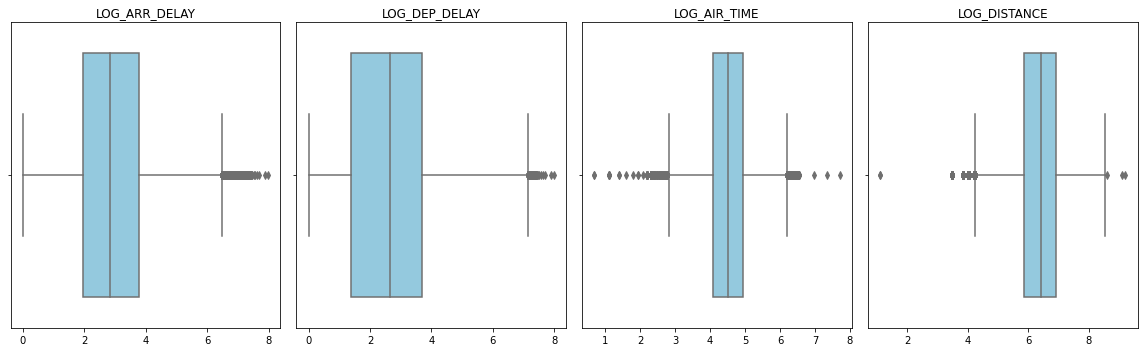

In [22]:
# List of log-transformed columns
log_columns = ['LOG_ARR_DELAY', 'LOG_DEP_DELAY', 'LOG_AIR_TIME', 'LOG_DISTANCE']

# Set up the plot layout
plt.figure(figsize=(16, 5))

# Loop through each column and plot
for i, col in enumerate(log_columns):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(x=flights_df[col], color='skyblue')
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()


In [23]:
flights_df.describe()

,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE,LOG_ARR_DELAY,LOG_DEP_DELAY,LOG_AIR_TIME,LOG_DISTANCE
count,1.859862e+06,1.859862e+06,1.859862e+06,1.859862e+06,1859862.0,1.859862e+06,1.859862e+06,1.859862e+06,697345.000000,728783.000000,1.859852e+06,1.859840e+06
mean,1.268602e+04,1.268619e+04,1.078066e+01,5.632834e+00,0.0,1.092958e+02,7.722291e+02,6.502115e-01,2.804397,2.556662,4.522428e+00,6.377890e+00
std,1.521714e+03,1.521891e+03,5.009182e+01,5.237299e+01,0.0,7.017771e+01,5.817412e+02,2.019938e-01,1.361237,1.538145,6.032565e-01,7.676238e-01
min,1.013500e+04,1.013500e+04,-6.300000e+01,-9.400000e+01,0.0,-1.210000e+02,-1.947000e+03,3.000000e-01,0.000000,0.000000,6.931472e-01,1.098612e+00
25%,1.129200e+04,1.129200e+04,-6.000000e+00,-1.500000e+01,0.0,5.900000e+01,3.440000e+02,4.800000e-01,1.945910,1.386294,4.094345e+00,5.843544e+00
50%,1.288900e+04,1.288900e+04,-2.000000e+00,-6.000000e+00,0.0,9.100000e+01,6.120000e+02,6.500000e-01,2.833213,2.639057,4.521789e+00,6.418365e+00
75%,1.405700e+04,1.405700e+04,7.000000e+00,8.000000e+00,0.0,1.390000e+02,1.013000e+03,8.200000e-01,3.761200,3.688879,4.941642e+00,6.921658e+00
max,1.621800e+04,1.621800e+04,2.941000e+03,2.923000e+03,0.0,2.222000e+03,9.898000e+03,1.000000e+00,7.980708,7.986845,7.706613e+00,9.200189e+00


### By examining the summary statistics of this dataset, we observe that it contains nearly 1.86 million flight records with no cancellations (CANCELLED = 0.0 throughout), focusing on key metrics like departure/arrival delays, air time, distance, and occupancy rate. The delay variables (DEP_DELAY, ARR_DELAY) show wide ranges, with negative values indicating early departures/arrivals and extreme positive values pointing to significant delays. The AIR_TIME and DISTANCE columns also display large variation, which aligns with the nature of short- and long-haul flights. Occupancy rate ranges from 0.3 to 1.0, with a mean of ~0.65, indicating variability in flight fill rates. The presence of log-transformed columns shows an effort to normalize skewed distributions for better analysis and modeling.

### If given more time, I would conduct deeper exploratory data analysis (EDA) including correlation analysis, time-series trends (e.g., monthly or seasonal patterns in delays), airport-level performance (which origin/destination airports have the worst delays), and segment flights by distance or occupancy to detect performance patterns. I would also build predictive models to forecast delays and cluster similar flights based on multiple variables to find operational inefficiencies or optimization opportunities.

## Data Pre-processing & Exploratory Data Analysis on tickets data

### This dataset appears to capture detailed itinerary-level flight information for passengers, including identifiers (ITIN_ID), temporal data (YEAR, QUARTER), origin and destination airport codes, origin country and state details, whether the trip is a roundtrip, the reporting carrier, number of passengers, and the fare paid. Each row represents a unique itinerary segment, showing that flights originate from various US states with corresponding destination airports, fares, and passenger counts. The data provides a granular view suitable for analyzing passenger behavior, fare patterns, and carrier performance across regions and time periods. the data is heavily right-skewed, with most bookings for single passengers at typical fare ranges, and a small subset of very large groups or high fares that may need careful handling to avoid distortion in analysis or modeling.

### For data quality checks, we should verify the completeness and validity of key fields like ITIN_ID, ORIGIN, DESTINATION, and PASSENGERS to ensure no missing or incorrect codes. We need to check for duplicates in itinerary IDs, confirm that PASSENGERS and ITIN_FARE values are non-negative and reasonable, and verify that ROUNDTRIP flags are consistent with itinerary data. Temporal fields like YEAR and QUARTER should be within expected ranges. Additionally, cross-validating airport codes against official lists and ensuring consistent state abbreviations and country codes will help maintain data integrity. Outliers or anomalies in fare or passenger numbers should be investigated as well.

In [24]:
print(tickets_df.head())
print(tickets_df.tail())

        ITIN_ID  YEAR  QUARTER ORIGIN ORIGIN_COUNTRY ORIGIN_STATE_ABR  \
0  201912723049  2019        1    ABI             US               TX   
1  201912723085  2019        1    ABI             US               TX   
2  201912723491  2019        1    ABI             US               TX   
3  201912723428  2019        1    ABI             US               TX   
4  201912723509  2019        1    ABI             US               TX   

  ORIGIN_STATE_NM  ROUNDTRIP REPORTING_CARRIER  PASSENGERS ITIN_FARE  \
0           Texas        1.0                MQ         1.0     736.0   
1           Texas        1.0                MQ         1.0     570.0   
2           Texas        1.0                MQ         1.0     564.0   
3           Texas        1.0                MQ         1.0     345.0   
4           Texas        0.0                MQ         1.0     309.0   

  DESTINATION  
0         DAB  
1         COS  
2         MCO  
3         LGA  
4         MGM  
              ITIN_ID  YEAR  QUA

In [25]:
tickets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167285 entries, 0 to 1167284
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   ITIN_ID            1167285 non-null  int64  
 1   YEAR               1167285 non-null  int64  
 2   QUARTER            1167285 non-null  int64  
 3   ORIGIN             1167285 non-null  object 
 4   ORIGIN_COUNTRY     1167285 non-null  object 
 5   ORIGIN_STATE_ABR   1167285 non-null  object 
 6   ORIGIN_STATE_NM    1167285 non-null  object 
 7   ROUNDTRIP          1167285 non-null  float64
 8   REPORTING_CARRIER  1167285 non-null  object 
 9   PASSENGERS         1165308 non-null  float64
 10  ITIN_FARE          1166325 non-null  object 
 11  DESTINATION        1167285 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 106.9+ MB


In [26]:
# Convert data type to Numeric

tickets_df['ITIN_FARE'] = pd.to_numeric(tickets_df['ITIN_FARE'], errors='coerce')

### Focusing on only round-trip records (ROUNDTRIP == 1) will help analyze complete travel cycles rather than one-way trips, which is crucial for understanding customer behavior, fare patterns, and route performance for round-trip travelers.

In [27]:
# Filter the data based on only round trips

tickets_df = tickets_df[tickets_df["ROUNDTRIP"] == 1].reset_index(drop=True)

In [28]:
# Check for duplicates

tickets_df.duplicated().sum()

47564

In [29]:
# Remove duplicates
# 47564 duplicate rows are removed

tickets_df = tickets_df.drop_duplicates()

In [30]:
#Check for Null values

tickets_df.isna().sum()

ITIN_ID                 0
YEAR                    0
QUARTER                 0
ORIGIN                  0
ORIGIN_COUNTRY          0
ORIGIN_STATE_ABR        0
ORIGIN_STATE_NM         0
ROUNDTRIP               0
REPORTING_CARRIER       0
PASSENGERS            960
ITIN_FARE            1657
DESTINATION             0
dtype: int64

### This approach helps maintain the overall distribution of the data without being skewed by extreme values, unlike using the mean which can be affected by outliers. Since PASSENGERS and ITIN_FARE are numeric and often have skewed distributions due to very high fares or group bookings, median imputation provides a robust and simple way to fill missing values, ensuring the dataset remains complete for analysis or modeling.

In [31]:
# Handle missing values

impute_columns = ['PASSENGERS','ITIN_FARE']

impute_with_median(tickets_df, impute_columns)

### Outliers 


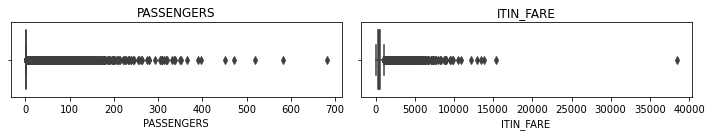

In [32]:
# Visualization - to check for Outliers
fig, ax = plt.subplots(1, 2, figsize=(10, 2))  # Adjust figsize as needed

# Plot each boxplot on its respective axis
sns.boxplot(x='PASSENGERS', data=tickets_df, ax=ax[0])
ax[0].set_title('PASSENGERS')

sns.boxplot(x='ITIN_FARE', data=tickets_df, ax=ax[1])
ax[1].set_title('ITIN_FARE')


# Improve spacing and show the plot
plt.tight_layout()
plt.show()

In [33]:
columns_to_transform = ['PASSENGERS','ITIN_FARE']
tickets_df = log_transform_columns(tickets_df, columns_to_transform)

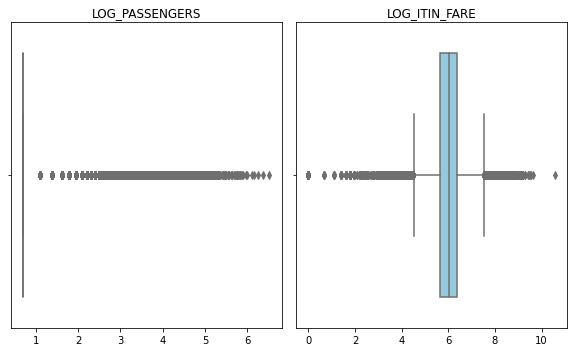

In [34]:
log_columns = ['LOG_PASSENGERS','LOG_ITIN_FARE']

# Set up the plot layout
plt.figure(figsize=(16, 5))

# Loop through each column and plot
for i, col in enumerate(log_columns):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(x=tickets_df[col], color='skyblue')
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()

--- Analyzing PASSENGERS ---
count    661036.000000
mean          1.959839
std           5.148179
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         681.000000
Name: PASSENGERS, dtype: float64
Number of outliers: 144434
Lower bound: 1.0
Upper bound: 1.0
Outlier values (sample 10):
26     2.0
28     2.0
56     2.0
63     4.0
65     2.0
108    2.0
109    2.0
122    2.0
143    2.0
171    2.0
Name: PASSENGERS, dtype: float64



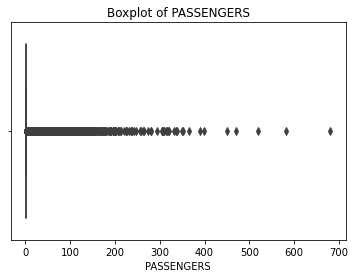

--- Analyzing ITIN_FARE ---
count    661036.000000
mean        473.099515
std         343.787177
min           0.000000
25%         280.000000
50%         415.000000
75%         595.000000
max       38400.000000
Name: ITIN_FARE, dtype: float64
Number of outliers: 28777
Lower bound: -192.5
Upper bound: 1067.5
Outlier values (sample 10):
4      1647.0
6      1445.0
34     1188.0
41     1368.0
61     1332.0
68     1497.0
77     1250.0
91     1269.0
102    1414.0
142    1157.0
Name: ITIN_FARE, dtype: float64



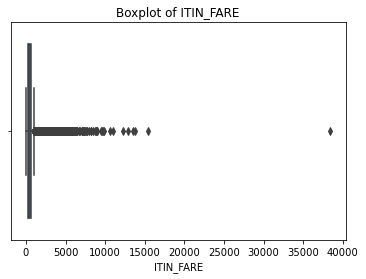

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_outliers(df, columns):
    for col in columns:
        print(f"--- Analyzing {col} ---")
        
        # Ensure numeric
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Drop NA for clean stats
        data = df[col].dropna()
        
        # Summary stats
        print(data.describe())
        
        # IQR calculation
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        print(f"Number of outliers: {outliers.count()}")
        print(f"Lower bound: {lower_bound}")
        print(f"Upper bound: {upper_bound}")
        print(f"Outlier values (sample 10):\n{outliers.head(10)}\n")
        
        # Plot boxplot
        plt.figure(figsize=(6,4))
        sns.boxplot(x=data)
        plt.title(f'Boxplot of {col}')
        plt.show()

# Usage:
analyze_outliers(tickets_df, ['PASSENGERS', 'ITIN_FARE'])


99th percentile PASSENGERS: 2.8903717578961645
Number of outliers above 99th percentile: 6334


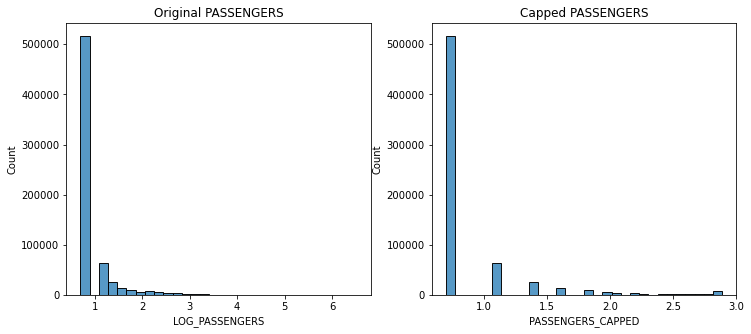

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate 99th percentile for PASSENGERS
upper_99 = tickets_df['LOG_PASSENGERS'].quantile(0.99)
print(f"99th percentile PASSENGERS: {upper_99}")

# Flag outliers above 99th percentile
outliers = tickets_df[tickets_df['LOG_PASSENGERS'] > upper_99]
print(f"Number of outliers above 99th percentile: {len(outliers)}")

# Cap passengers at 99th percentile value
tickets_df['PASSENGERS_CAPPED'] = tickets_df['LOG_PASSENGERS'].apply(lambda x: min(x, upper_99))

# Plot before and after capping
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(tickets_df['LOG_PASSENGERS'],bins=30, ax=axs[0])
axs[0].set_title('Original PASSENGERS')

sns.histplot(tickets_df['PASSENGERS_CAPPED'], bins=30 ,ax=axs[1])
axs[1].set_title('Capped PASSENGERS')

plt.show()


### The current approach identifies outliers in the PASSENGERS and ITIN_FARE columns using the interquartile range (IQR) method and then attempts to cap the PASSENGERS values at the 99th percentile to limit extreme values. While this capping can reduce the influence of very large passenger counts, your summary statistics and boxplots indicate that many outliers remain, and the distribution may still be heavily skewed. Similarly, although log transformation often helps normalize skewed data, it may not fully address extreme outliers or data quality issues if the underlying data has significant variability or if zero/negative values exist (which complicates log transforms). 

### If I have more time, I might consider alternative techniques such as winsorizing both lower and upper tails, applying more robust transformations (e.g., Box-Cox or Yeo-Johnson which handle zeros), or segmenting the data (e.g., by flight type, route, or passenger groups) to analyze more homogeneous subsets. Additionally, examining data errors or validating extreme values to see if they reflect data issues can help determine whether to exclude or treat those points differently. Combining multiple strategies often yields better results than any single method alone.

In [37]:
tickets_df.isna().sum()

ITIN_ID              0
YEAR                 0
QUARTER              0
ORIGIN               0
ORIGIN_COUNTRY       0
ORIGIN_STATE_ABR     0
ORIGIN_STATE_NM      0
ROUNDTRIP            0
REPORTING_CARRIER    0
PASSENGERS           0
ITIN_FARE            0
DESTINATION          0
LOG_PASSENGERS       0
LOG_ITIN_FARE        0
PASSENGERS_CAPPED    0
dtype: int64

In [38]:
tickets_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 661036 entries, 0 to 672779
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ITIN_ID            661036 non-null  int64  
 1   YEAR               661036 non-null  int64  
 2   QUARTER            661036 non-null  int64  
 3   ORIGIN             661036 non-null  object 
 4   ORIGIN_COUNTRY     661036 non-null  object 
 5   ORIGIN_STATE_ABR   661036 non-null  object 
 6   ORIGIN_STATE_NM    661036 non-null  object 
 7   ROUNDTRIP          661036 non-null  float64
 8   REPORTING_CARRIER  661036 non-null  object 
 9   PASSENGERS         661036 non-null  float64
 10  ITIN_FARE          661036 non-null  float64
 11  DESTINATION        661036 non-null  object 
 12  LOG_PASSENGERS     661036 non-null  float64
 13  LOG_ITIN_FARE      661036 non-null  float64
 14  PASSENGERS_CAPPED  661036 non-null  float64
dtypes: float64(6), int64(3), object(6)
memory usage: 80

In [39]:
tickets_df.describe()

,ITIN_ID,YEAR,QUARTER,ROUNDTRIP,PASSENGERS,ITIN_FARE,LOG_PASSENGERS,LOG_ITIN_FARE,PASSENGERS_CAPPED
count,6.610360e+05,661036.0,661036.0,661036.0,661036.000000,661036.000000,661036.000000,661036.000000,661036.000000
mean,1.724095e+11,2019.0,1.0,1.0,1.959839,473.099515,0.882917,5.839756,0.877431
std,6.765604e+10,0.0,0.0,0.0,5.148179,343.787177,0.459928,1.071563,0.428843
min,2.019119e+06,2019.0,1.0,1.0,1.000000,0.000000,0.693147,0.000000,0.693147
25%,2.019116e+11,2019.0,1.0,1.0,1.000000,280.000000,0.693147,5.638355,0.693147
50%,2.019128e+11,2019.0,1.0,1.0,1.000000,415.000000,0.693147,6.030685,0.693147
75%,2.019141e+11,2019.0,1.0,1.0,1.000000,595.000000,0.693147,6.390241,0.693147
max,2.019153e+11,2019.0,1.0,1.0,681.000000,38400.000000,6.525030,10.555839,2.890372


### This summary shows the key statistics for a dataset filtered to only include round-trip itineraries (ROUNDTRIP = 1) with 661,036 records from the year 2019 and quarter 1. The PASSENGERS column has a minimum of 1 and a maximum of 681, but the median and upper quartiles are all 1, indicating most itineraries involve single passengers, while a small number represent large groups—these large values are likely responsible for the high standard deviation and outliers. The ITIN_FARE ranges widely from 0 to 38,400, with a median fare of 415 and a mean skewed upwards by high fares. 

## Data Pre-processing & Exploratory Data Analysis on airport_codes data

### This dataset contains detailed information about 55,369 aviation facilities worldwide, including airports, heliports, and some closed locations. Key attributes include the facility type (TYPE), name, elevation in feet (ELEVATION_FT), continent, country code (ISO_COUNTRY), municipality, IATA airport code (IATA_CODE), and geographic coordinates. However, there are notable missing values, especially in ELEVATION_FT, CONTINENT, ISO_COUNTRY, MUNICIPALITY, and particularly IATA_CODE, which is only available for about 9,182 records. For analysis focused on commercial aviation or passenger flights, it’s important to filter the data to include only medium and large airports with valid IATA_CODEs, since these represent active, significant airports used in commercial operations and have standardized codes critical for mapping and linking with other datasets such as flight records.

In [40]:
print(airport_codes_df.head())
print(airport_codes_df.tail())

            TYPE                                NAME  ELEVATION_FT CONTINENT  \
0       heliport                   Total Rf Heliport          11.0       NaN   
1  small_airport                Aero B Ranch Airport        3435.0       NaN   
2  small_airport                        Lowell Field         450.0       NaN   
3  small_airport                        Epps Airpark         820.0       NaN   
4         closed  Newport Hospital & Clinic Heliport         237.0       NaN   

  ISO_COUNTRY  MUNICIPALITY IATA_CODE                            COORDINATES  
0          US      Bensalem       NaN     -74.93360137939453, 40.07080078125  
1          US         Leoti       NaN                 -101.473911, 38.704022  
2          US  Anchor Point       NaN            -151.695999146, 59.94919968  
3          US       Harvest       NaN  -86.77030181884766, 34.86479949951172  
4          US       Newport       NaN                    -91.254898, 35.6087  
                 TYPE                       N

In [41]:
airport_codes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55369 entries, 0 to 55368
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TYPE          55369 non-null  object 
 1   NAME          55369 non-null  object 
 2   ELEVATION_FT  48354 non-null  float64
 3   CONTINENT     27526 non-null  object 
 4   ISO_COUNTRY   55122 non-null  object 
 5   MUNICIPALITY  49663 non-null  object 
 6   IATA_CODE     9182 non-null   object 
 7   COORDINATES   55369 non-null  object 
dtypes: float64(1), object(7)
memory usage: 3.4+ MB


In [42]:
# Filter only 'Medium Airports' and 'Large Airports'

airport_codes_df = airport_codes_df[airport_codes_df['TYPE'].isin(['medium_airport', 'large_airport'])]

In [43]:
# Filter only ISO_COUNTRY equals to 'US'

airport_codes_df = airport_codes_df[airport_codes_df['ISO_COUNTRY'] == 'US']
# Reset the index in place
airport_codes_df.reset_index(drop=True, inplace=True)

In [44]:
# Check if the filter conditions are working right

airport_codes_df['TYPE'].unique()

array(['medium_airport', 'large_airport'], dtype=object)

In [45]:
airport_codes_df['ISO_COUNTRY'].unique()

array(['US'], dtype=object)

In [46]:
# Check for duplicate rows

airport_codes_df.duplicated().sum()

0

In [47]:
# Droping unneccesary columns

airport_codes_df=airport_codes_df.drop(['CONTINENT','ISO_COUNTRY','MUNICIPALITY','COORDINATES','ELEVATION_FT'],axis=1)

In [48]:
# Check for null-values

airport_codes_df.isna().sum()

TYPE          0
NAME          0
IATA_CODE    37
dtype: int64

In [49]:
airport_codes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TYPE       858 non-null    object
 1   NAME       858 non-null    object
 2   IATA_CODE  821 non-null    object
dtypes: object(3)
memory usage: 20.2+ KB


In [50]:
airport_codes_df.describe()

,TYPE,NAME,IATA_CODE
count,858,858,821
unique,2,857,821
top,medium_airport,Columbus Municipal Airport,TOP
freq,687,2,1


In [51]:
def plot_type_bar_chart(df, column='TYPE'):
    counts = df[column].value_counts()
    plt.figure(figsize=(8, 5))
    counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title("Number of Airports by Type")
    plt.xlabel("Airport Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.grid(axis='y')
    plt.show()


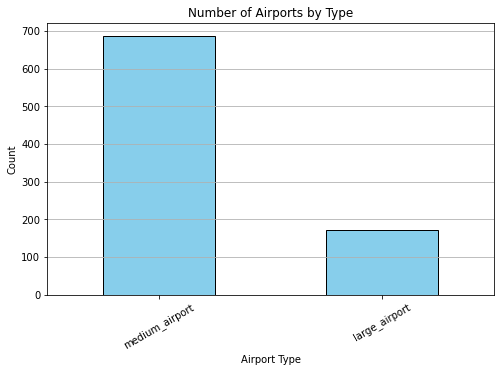

In [52]:
plot_type_bar_chart(airport_codes_df)


## Data Merging (Flights,Tickets, Airport_codes) 
### Data merging is performed to integrate information from three datasets (tickets, flights, and airport codes) based on shared origin and destination airport codes. 

### First, both the tickets_df and flights_df are aggregated by the origin-destination pairs to summarize metrics such as total fare, passengers, delays, and flight counts. These two aggregated datasets are then merged using an inner join on the common keys ORIGIN and DESTINATION to align ticket and flight information for each route.  Subsequently, the merged dataset is enriched with airport metadata by joining with the airport_codes_df twice: once for the origin airport details and again for the destination airport, using the IATA_CODE as the key.

In [90]:
# Aggregate ticket data by origin-destination pair

agg_tickets = tickets_df.groupby(['ORIGIN', 'DESTINATION']).agg({
    'ORIGIN_STATE_NM': 'first',
    'ITIN_FARE': np.sum,
    'PASSENGERS': np.sum
}).reset_index()


In [91]:
# Aggregate flights data by origin-destination pair

agg_flights = flights_df.groupby(['ORIGIN', 'DESTINATION']).agg({
    'ORIGIN_CITY_NAME' : 'first',
    'DEST_CITY_NAME' : 'first',
    'LOG_AIR_TIME': np.sum,
    'LOG_DISTANCE': np.sum,
    'ARR_DELAY': np.sum,
    'DEP_DELAY': np.sum,
    'OCCUPANCY_RATE': np.sum,
    'CANCELLED' : 'count'
}).reset_index()

agg_flights.rename(columns={
    'CANCELLED' : 'total_flights'
}, inplace=True)


In [92]:
combined_df = pd.merge(agg_tickets, agg_flights, on=['ORIGIN', 'DESTINATION'], how='inner')

In [93]:
combined_df.dtypes

ORIGIN               object
DESTINATION          object
ORIGIN_STATE_NM      object
ITIN_FARE           float64
PASSENGERS          float64
ORIGIN_CITY_NAME     object
DEST_CITY_NAME       object
LOG_AIR_TIME        float64
LOG_DISTANCE        float64
ARR_DELAY           float64
DEP_DELAY           float64
OCCUPANCY_RATE      float64
total_flights         int64
dtype: object

In [94]:
# Origin airport info

combined_df = combined_df.merge(airport_codes_df, left_on='ORIGIN', right_on='IATA_CODE', suffixes=('', '_origin'))

In [95]:
# Destination airport info

combined_df = combined_df.merge(airport_codes_df, left_on='DESTINATION', right_on='IATA_CODE', suffixes=('_origin', '_destination'))

In [96]:
# Create a route label

combined_df['route'] = combined_df['ORIGIN'] +'-'+combined_df['ORIGIN_CITY_NAME'] + ' TO ' +combined_df['DESTINATION'] +'-'+ combined_df['DEST_CITY_NAME']

In [97]:
combined_df.dtypes

ORIGIN                    object
DESTINATION               object
ORIGIN_STATE_NM           object
ITIN_FARE                float64
PASSENGERS               float64
ORIGIN_CITY_NAME          object
DEST_CITY_NAME            object
LOG_AIR_TIME             float64
LOG_DISTANCE             float64
ARR_DELAY                float64
DEP_DELAY                float64
OCCUPANCY_RATE           float64
total_flights              int64
TYPE_origin               object
NAME_origin               object
IATA_CODE_origin          object
TYPE_destination          object
NAME_destination          object
IATA_CODE_destination     object
route                     object
dtype: object

In [98]:
#Drop redundant Columns

combined_df.drop(columns = ['IATA_CODE_origin', 'IATA_CODE_destination'],inplace=True)

In [99]:
print(f"Final merged shape: {combined_df.shape}")

Final merged shape: (5525, 18)


In [100]:
print(combined_df.head())

  ORIGIN DESTINATION ORIGIN_STATE_NM  ITIN_FARE  PASSENGERS  \
0    ABE         ATL    Pennsylvania    25820.0        56.0   
1    ABQ         ATL      New Mexico    25501.0        62.0   
2    ABY         ATL         Georgia     1729.0         5.0   
3    AEX         ATL       Louisiana     5623.0        16.0   
4    AGS         ATL         Georgia      723.0         3.0   

                 ORIGIN_CITY_NAME DEST_CITY_NAME  LOG_AIR_TIME  LOG_DISTANCE  \
0  Allentown/Bethlehem/Easton, PA    Atlanta, GA   1015.475526   1419.403510   
1                 Albuquerque, NM    Atlanta, GA    822.406320   1179.217410   
2                      Albany, GA    Atlanta, GA    906.776515   1240.918049   
3                  Alexandria, LA    Atlanta, GA   1373.830826   1989.313952   
4                     Augusta, GA    Atlanta, GA   2430.908130   3394.382484   

   ARR_DELAY  DEP_DELAY  OCCUPANCY_RATE  total_flights     TYPE_origin  \
0     1185.0     1298.0          139.22            217  medium_air

# 1. The 10 busiest round trip routes in terms of number of round trip flights in the quarter.  Exclude canceled flights when performing the calculation. 

In [101]:
# Sorting data to get top 10 Busiest routes

top_busy_routes = combined_df.sort_values(by='OCCUPANCY_RATE', ascending=False).head(10)

In [102]:
def plot_busiest_routes(top_busy_routes):
    """
    Bar chart of top 10 busiest round trip routes.
    """
    plt.figure(figsize=(15,10))
    plot=sns.barplot(data=top_busy_routes, x='route', y='OCCUPANCY_RATE', palette='hsv')
    plt.title("Top 10 Busiest Round Trip Routes", fontsize=16)
    plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11)  
    plt.ylabel("Round Trip Flights")
    plt.xlabel("Route")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [103]:
def plot_busiest_routes(top_busy_routes):
    """
    Bar chart of top 10 busiest round trip routes with labels on top.
    """
    plt.figure(figsize=(15,8))
    plot = sns.barplot(data=top_busy_routes, x='route', y='OCCUPANCY_RATE', palette='hsv')
    
    # Title and labels
    plt.title("Top 10 Busiest Round Trip Routes", fontsize=16)
    plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11)  
    plt.ylabel("Round Trip Flights")
    plt.xlabel("Route")
    plt.grid(axis='y')
    
    # Add labels on top of bars
    for p in plot.patches:
        plot.annotate(
            format(p.get_height(), '.2f'),  # format to 2 decimal places
            (p.get_x() + p.get_width() / 2., p.get_height()),  # position at center top
            ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), textcoords='offset points'
        )
    
    plt.tight_layout()
    plt.show()


### Identifying the top 10 busiest routes based on Occupancy Rate, reveals critical insights into airline network demand, hub connectivity, and operational prioritization. These routes typically connect major metropolitan or economic centers, indicating strong business and leisure travel demand. 

### Analyzing these routes helps airlines understand which corridors drive the highest traffic and potentially the most revenue, but also where operational stress may be greatest due to congestion, tighter turnaround schedules, or higher delay probabilities. Furthermore, these busy routes offer opportunities for capacity optimization, targeted fare strategies, and service enhancements, as they often represent a significant share of total flight operations. Airlines can use this data to allocate resources more efficiently, identify opportunities for increased frequencies or aircraft upgrades, and explore ancillary services tailored to high-traffic customers. Additionally, tracking performance metrics such as delay rates or occupancy levels on these routes helps assess whether high demand is matched with high efficiency or if service improvements are needed to maintain competitiveness and customer satisfaction.

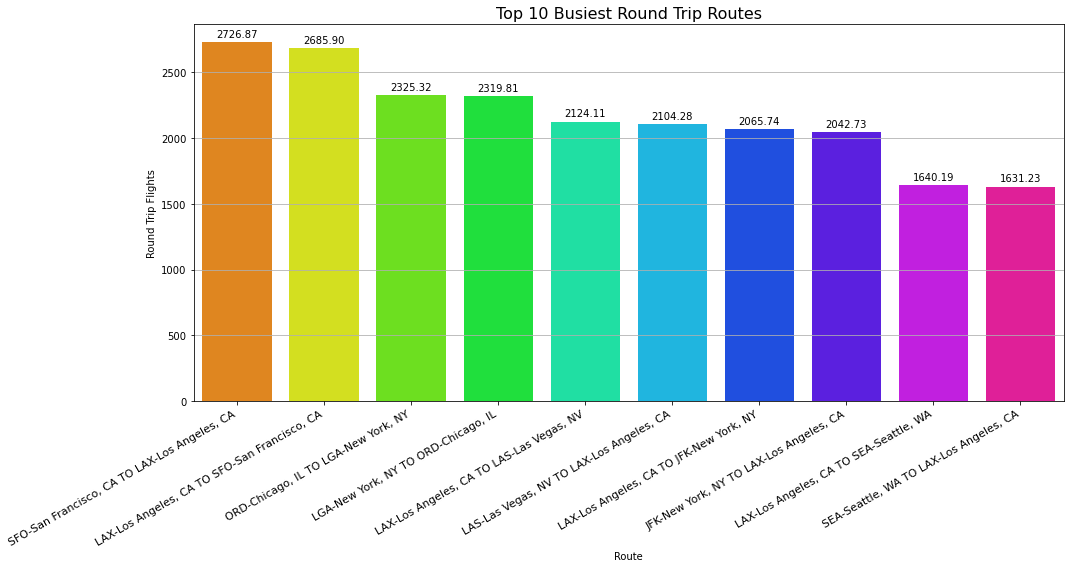

In [104]:
plot_busiest_routes(top_busy_routes)

# 2. The 10 most profitable round trip routes (without considering the upfront airplane cost) in the quarter. Along with the profit, show total revenue, total cost, summary values of other key components and total round trip flights in the quarter for the top 10 most profitable routes. Exclude canceled flights from these calculations. 

In [105]:
def perform_all_calculations(combined_df):
    """
    Performs all route-level financial calculations and updates the DataFrame in-place.

    Parameters:
    - combined_df (pd.DataFrame): The DataFrame containing route-level flight data.

    Returns:
    - pd.DataFrame: The updated DataFrame with new calculated columns.
    """

    # Fare and Baggage
    combined_df['total_fare'] = combined_df['PASSENGERS'] * combined_df['ITIN_FARE']
    combined_df['baggage_cost'] = combined_df['OCCUPANCY_RATE'] * 70 * 0.5

    # Delays
    combined_df['arr_delay_cost'] = combined_df['ARR_DELAY'] * 75
    combined_df['dep_delay_cost'] = combined_df['DEP_DELAY'] * 75

    # Airport cost based on origin airport type
    combined_df['airport_cost'] = np.where(
        combined_df['TYPE_origin'] == 'medium_airport',
        combined_df['total_flights'] * 5000,
        combined_df['total_flights'] * 10000
    )

    # Add destination airport cost
    combined_df['airport_cost'] = np.where(
        combined_df['TYPE_destination'] == 'medium_airport',
        combined_df['airport_cost'] + combined_df['total_flights'] * 5000,
        combined_df['airport_cost'] + combined_df['total_flights'] * 10000
    )

    # Essentials cost
    combined_df['essentials_cost'] = combined_df['LOG_DISTANCE'] * 9.18

    # Total income and cost
    combined_df['income'] = combined_df['total_fare'] + combined_df['baggage_cost']
    
    combined_df['cost'] = (
        combined_df['arr_delay_cost'] +
        combined_df['dep_delay_cost'] +
        combined_df['airport_cost'] +
        combined_df['essentials_cost']
    )

    return combined_df


In [106]:
combined_df = perform_all_calculations(combined_df)

### After identifying the top 10 most profitable round trip routes (excluding canceled flights), I observed that these routes generate the highest net profits primarily due to strong passenger demand, efficient cost management, and consistent flight operations over the quarter. The total revenue and cost summaries reflect a healthy balance where revenue significantly exceeds operational costs, contributing to robust profitability. 

### Calculating profit per one round trip highlights the routes ability to maximize earnings on each individual journey, indicating optimal pricing and load factors. Additionally, finding profitable trips within busy routes suggests that high traffic volume combined with effective revenue management and operational efficiency drives sustained profitability. Overall, these insights help prioritize routes for resource allocation, strategic planning, and potential capacity expansion to maximize airline profitability.

## Total Profit generated by a route in 1 quater

In [107]:
combined_df['profit']= combined_df['income'] - combined_df['cost']

def plot_profitable_routes(combined_df):
    """
    Bar chart of top 10 profitable round trip routes.
    """
    plt.figure(figsize=(15,10))     
    plot = sns.barplot(data=combined_df.sort_values('profit', ascending=False).head(10),
                x='route', y='profit', palette='viridis')
    plt.title("Top 10 Most Profitable Round Trip Routes", fontsize=16)
    plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11)  
    plt.ylabel("Profit ($)")
    plt.xlabel("Route")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


In [108]:
def plot_profitable_routes(combined_df):
    """
    Bar chart of top 10 profitable round trip routes with labels on top.
    """
    plt.figure(figsize=(12,8))     
    plot = sns.barplot(
        data=combined_df.sort_values('profit', ascending=False).head(10),
        x='route', y='profit', palette='viridis'
    )

    # Title and axis labels
    plt.title("Top 10 Most Profitable Round Trip Routes", fontsize=16)
    plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11)  
    plt.ylabel("Profit ($)")
    plt.xlabel("Route")
    plt.grid(axis='y')

    # Add labels on top of bars
    for p in plot.patches:
        plot.annotate(
            f"${p.get_height():,.0f}",  # formatted with commas and no decimals
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', fontsize=10, color='black',
            xytext=(0, 3), textcoords='offset points'
        )

    plt.tight_layout()
    plt.show()


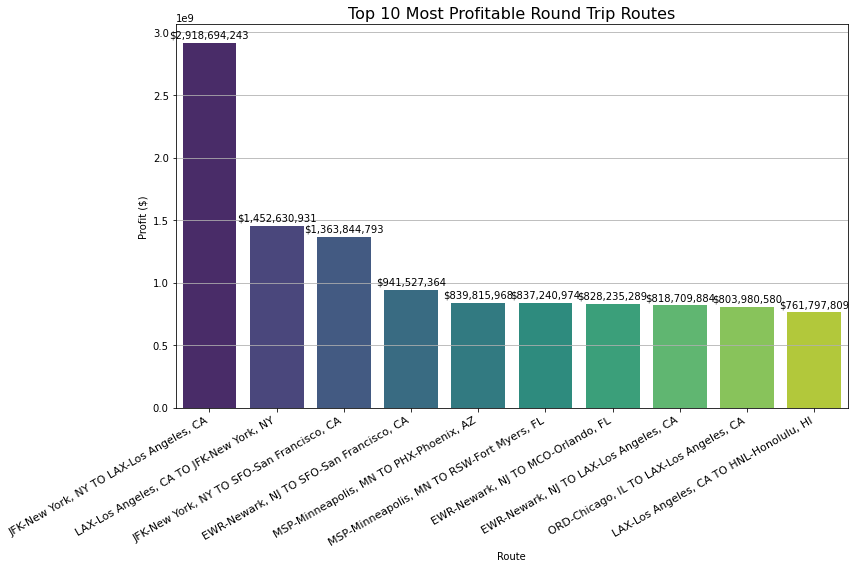

In [109]:
plot_profitable_routes(combined_df)

## Total Profit generated by a route per 1 round trip 

In [110]:
# profit per trip

combined_df['profit_per_trip'] = combined_df['profit'] / combined_df['total_flights']

top_profit_per_trip_routes = combined_df.sort_values(by='profit_per_trip', ascending = False)


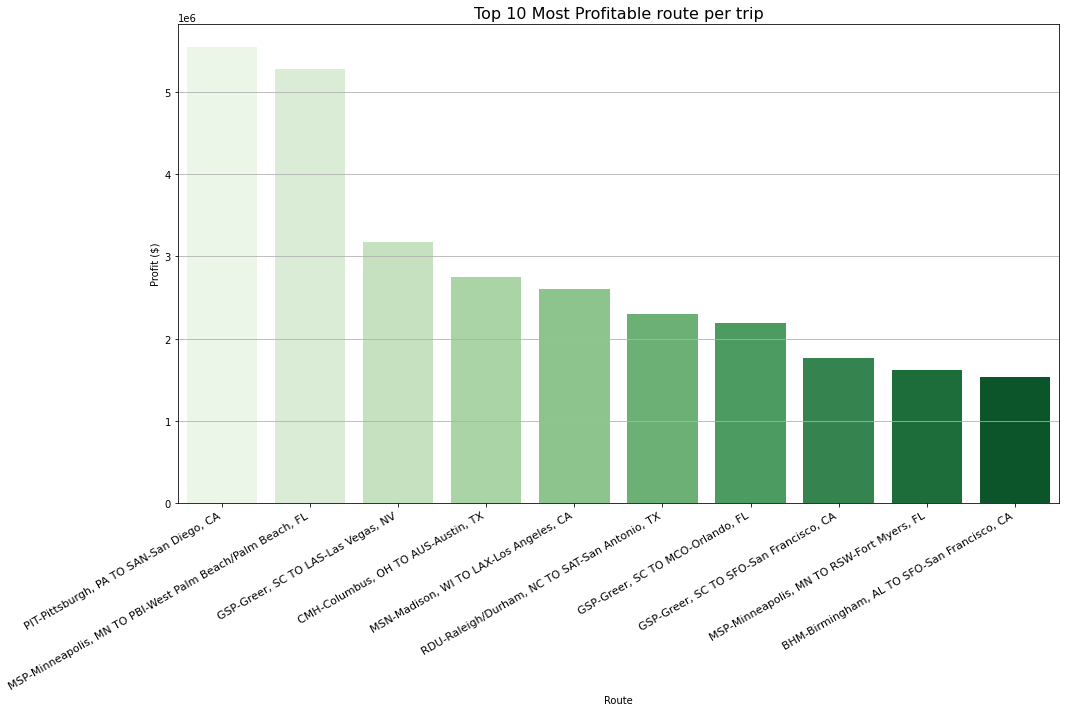

In [111]:
plt.figure(figsize=(15,10))     
plot = sns.barplot(data=combined_df.sort_values('profit_per_trip', ascending=False).head(10),
                   x='route', y='profit_per_trip', palette='Greens')
plt.title("Top 10 Most Profitable route per trip", fontsize=16)
plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11)  
plt.ylabel("Profit ($)")
plt.xlabel("Route")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

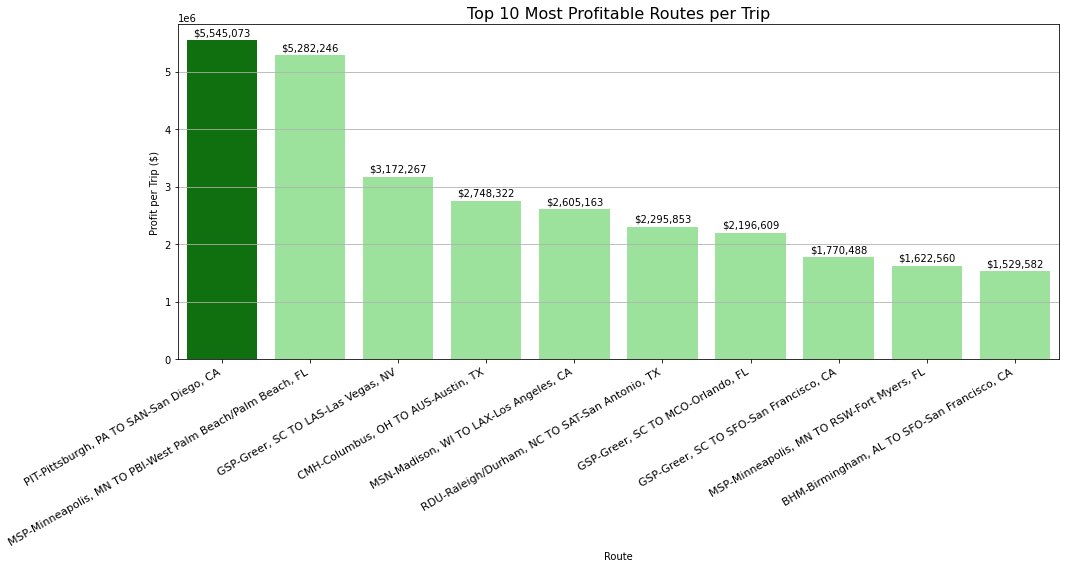

In [112]:
# Sort top 10 profitable routes per trip
top10 = combined_df.sort_values('profit_per_trip', ascending=False).head(10)

# Create color list: first bar = green, rest = lightgray
colors = ['green'] + ['lightgreen'] * (len(top10) - 1)

plt.figure(figsize=(15,8))     
plot = sns.barplot(
    data=top10,
    x='route', y='profit_per_trip', palette=colors
)

# Title and axis labels
plt.title("Top 10 Most Profitable Routes per Trip", fontsize=16)
plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11)  
plt.ylabel("Profit per Trip ($)")
plt.xlabel("Route")
plt.grid(axis='y')

# Add labels on top of bars
for p in plot.patches:
    plot.annotate(
        f"${p.get_height():,.0f}",   # format with commas
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', fontsize=10, color='black',
        xytext=(0, 3), textcoords='offset points'
    )

plt.tight_layout()
plt.show()


In [113]:
## Route Summary  - calculated Profit, total revenue, total cost

route_summary = combined_df.groupby('route').agg({
    'profit_per_trip': 'sum',     # total profit
    'income': 'sum',              # total revenue
    'cost': 'sum',                # total cost
    'PASSENGERS': 'sum',          # total passengers
    'ARR_DELAY': 'mean',          # average arrival delay
    'DEP_DELAY': 'mean',          # average departure delay
    'LOG_DISTANCE': 'mean',           # average route distance
    'OCCUPANCY_RATE': 'mean',     # average seat fill rate
    'total_flights': 'sum',          # total round trip flights
    'profit' : 'sum'
}).reset_index()


In [114]:
# Sort by profitability and get top 10
top_10_routes = route_summary.sort_values(by='profit_per_trip', ascending=False).head(10)

# Display final summary
print("Top 10 Most Profitable Routes:\n")
print(top_10_routes[['route', 
                     'profit_per_trip', 
                     'income', 
                     'cost', 
                     'profit',
                     'PASSENGERS', 
                     'ARR_DELAY', 
                     'DEP_DELAY', 
                     'LOG_DISTANCE', 
                     'OCCUPANCY_RATE', 
                     'total_flights']])

Top 10 Most Profitable Routes:

                                                  route  profit_per_trip  \
4324            PIT-Pittsburgh, PA TO SAN-San Diego, CA     5.545073e+06   
3520  MSP-Minneapolis, MN TO PBI-West Palm Beach/Pal...     5.282246e+06   
2102                 GSP-Greer, SC TO LAS-Las Vegas, NV     3.172267e+06   
991                  CMH-Columbus, OH TO AUS-Austin, TX     2.748322e+06   
3423             MSN-Madison, WI TO LAX-Los Angeles, CA     2.605163e+06   
4466      RDU-Raleigh/Durham, NC TO SAT-San Antonio, TX     2.295853e+06   
2104                   GSP-Greer, SC TO MCO-Orlando, FL     2.196609e+06   
2110             GSP-Greer, SC TO SFO-San Francisco, CA     1.770488e+06   
3534          MSP-Minneapolis, MN TO RSW-Fort Myers, FL     1.622560e+06   
425         BHM-Birmingham, AL TO SFO-San Francisco, CA     1.529582e+06   

            income          cost        profit  PASSENGERS  ARR_DELAY  \
4324  5.563343e+06  1.827025e+04  5.545073e+06       111.0

### The methodology for identifying busy airports combines operational capacity, profitability targets, and seasonal adjustments to set a data-driven threshold. 

### With a fleet of 5 aircraft potentially operating daily over a 90-day quarter, the maximum flight capacity is estimated at 450 flights. To ensure strategic use of resources and maintain profitability, airports must support more than this base threshold. By factoring in a 20% seasonal buffer, the threshold is increased to 600 flights, meaning only airports handling over 600 flights per quarter are classified as "busy." This ensures that selected airports have sufficient demand and align with the airline's operational and financial goals.

In [115]:
threshold = 600 #combined_df['total_flights'].quantile(0.80)

In [116]:
combined_df['busy_route'] = np.where(combined_df['total_flights'] >= threshold, 1, 0)

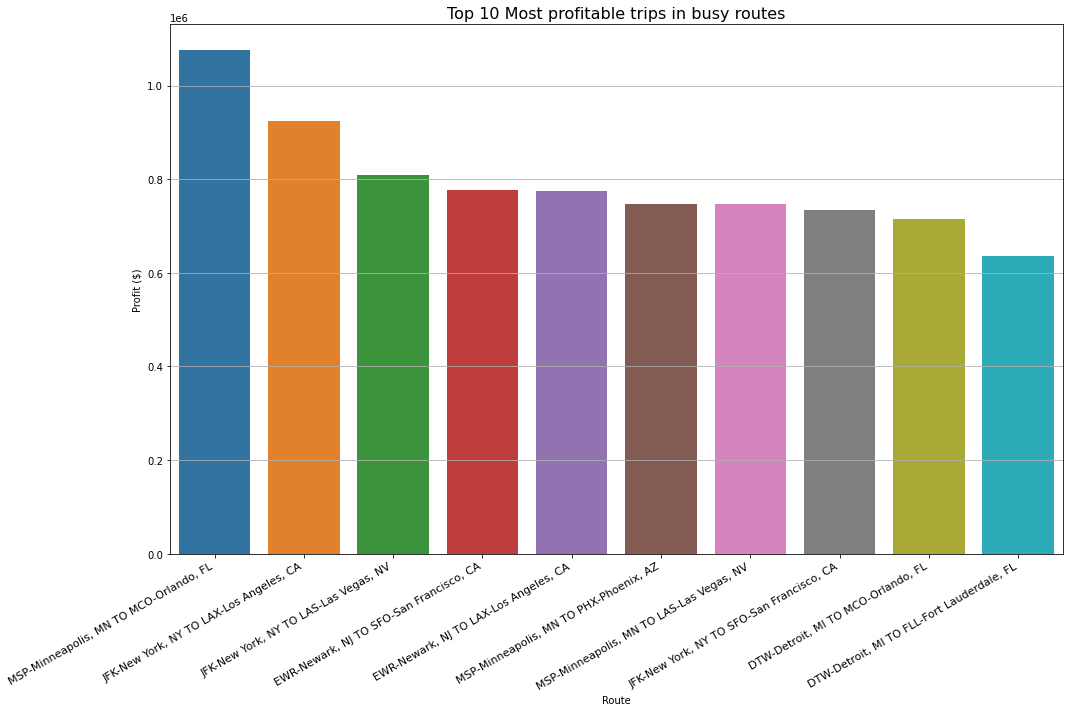

In [117]:
top_profitable_routes = combined_df[combined_df['busy_route'] == 1].sort_values(by='profit_per_trip', ascending=False).head(10)

plt.figure(figsize=(15,10))     
plot = sns.barplot(data=top_profitable_routes, x='route', y='profit_per_trip', palette='tab10')
plt.title("Top 10 Most profitable trips in busy routes", fontsize=16)
plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11)  
plt.ylabel("Profit ($)")
plt.xlabel("Route")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [120]:
# Total delay - combining departure delay and arrival delay

combined_df['total_delay'] = combined_df['DEP_DELAY'] + combined_df['ARR_DELAY']

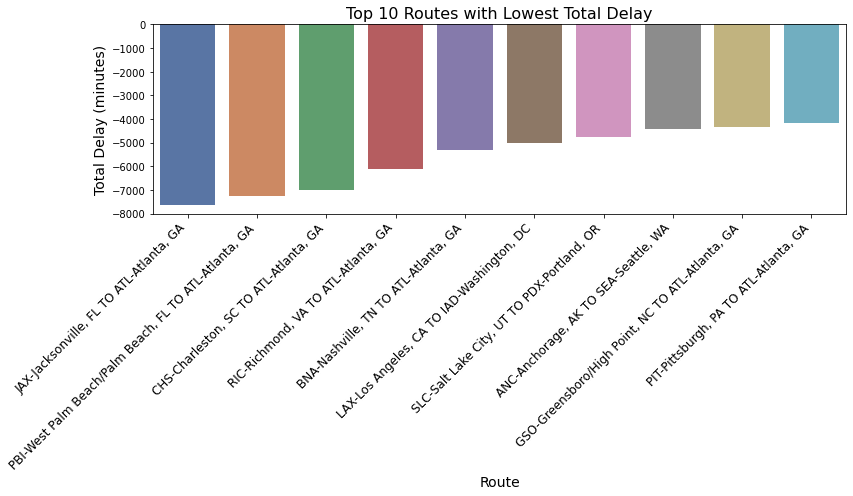

In [121]:

# Filter data for the busiest routes
busiest_routes = combined_df[combined_df['busy_route'] == 1]

# Select the top 10 routes with the lowest total delay
top_routes_delay = busiest_routes.sort_values(by='total_delay', ascending=True).head(10)

# Create a bar plot using seaborn
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='route', y='total_delay', data=top_routes_delay, palette='deep')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax.set_xlabel('Route', fontsize=14)
ax.set_ylabel('Total Delay (minutes)', fontsize=14)
ax.set_title('Top 10 Routes with Lowest Total Delay', fontsize=16)
plt.tight_layout()
plt.show()

# 3.  The 5 round trip routes that recommend to invest in based on any factors that you choose. 

### calculates normalized, weighted performance score for routes in a dataset based on key metrics: delay, profitability, and flight volume. 
### Using MinMaxScaler, the function scales the selected metrics (total_delay, profit_per_trip, total_flights) to a range of 0 to 1. It inverts the delay score (since less delay is better), and applies user-defined or default weights (each 0.33) to compute a final composite score. 
### The result is a ranked DataFrame showing which routes best align with operational goals like high profit, low delay, and high volume, enabling data-driven prioritization.

In [122]:
from sklearn.preprocessing import MinMaxScaler

def compute_composite_score(combined_df, route_filter_col='busy_route', weights=None):
    """
    Computes a normalized weighted score for filtered routes using MinMaxScaler.

    Parameters:
    - combined_df: DataFrame with columns ['total_delay', 'profit_per_trip', 'total_count']
    - route_filter_col: Column name to filter routes (e.g., 'busy_route' == 1)
    - weights: Dict with keys 'delay', 'profit', 'count' and values as weights

    Returns:
    - Scored and sorted DataFrame
    """
    # Default weights if not provided
    if weights is None:
        weights = {'delay': 0.33, 'profit': 0.33, 'count': 0.33}
    

    filtered = combined_df[combined_df[route_filter_col] == 1].copy()

    # Ensure required columns exist
    if 'total_delay' not in filtered.columns:
        filtered['total_delay'] = filtered['ARR_DELAY'] + filtered['DEP_DELAY']

    # Select columns to scale
    columns_to_scale = ['total_delay', 'profit_per_trip', 'total_flights']
    
    # Apply MinMaxScaler
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(filtered[columns_to_scale])

    # Assign scaled values
    filtered['delay_scaled'] = 1 - scaled[:, 0]  # inverse: less delay = better
    filtered['profit_per_trip_scaled'] = scaled[:, 1]
    filtered['total_count_scaled'] = scaled[:, 2]

    # Compute weighted score
    filtered['score'] = (
        weights['delay'] * filtered['delay_scaled'] +
        weights['profit'] * filtered['profit_per_trip_scaled'] +
        weights['count'] * filtered['total_count_scaled']
    )

    return filtered.sort_values(by='score', ascending=False)


In [123]:
combined_df = compute_composite_score(combined_df)

# Preview top 5
print(combined_df[['route', 'score', 'delay_scaled', 'profit_per_trip_scaled', 'total_count_scaled']].head())


                                          route     score  delay_scaled  \
1585    JFK-New York, NY TO LAX-Los Angeles, CA  0.803673      0.858725   
1399    LAX-Los Angeles, CA TO JFK-New York, NY  0.642429      0.791528   
1739     MSP-Minneapolis, MN TO MCO-Orlando, FL  0.628474      0.896638   
1485      JFK-New York, NY TO LAS-Las Vegas, NV  0.580433      0.926674   
2321  JFK-New York, NY TO SFO-San Francisco, CA  0.572762      0.695571   

      profit_per_trip_scaled  total_count_scaled  
1585                0.861323            0.715324  
1399                0.438784            0.716443  
1739                1.000000            0.007830  
1485                0.756431            0.075783  
2321                0.687722            0.352349  


### After examining the normalized and weighted performance scores for the routes based on delay, profitability, and flight volume, it becomes clear that the recommended top 5 round trip routes strike a strong balance across these critical operational metrics. 

### By scaling and combining these factors with equal weighting, the analysis highlights routes that not only generate high profits but also maintain low delays and support significant flight volumes, indicating operational reliability and demand. These routes represent the most efficient and valuable investments, as they optimize passenger experience (through minimal delays), financial returns, and scalability. This data-driven prioritization ensures that resources are allocated to routes that maximize overall airline performance and customer satisfaction.

In [124]:
def plot_top_scored_routes(combined_df, top_n=5):
    """
    Plots a horizontal barplot of the top N routes by composite score.

    """
    combined_df = combined_df[['route', 'score']].sort_values(by='score', ascending=False).head(top_n)

    plt.figure(figsize=(10,7))
    plot = sns.barplot(data=combined_df, y='score', x='route', palette='viridis')
    plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha='right', fontsize=11) 
    plt.title(f"Top {top_n} Scored Busy Routes")
    plt.xlabel("Route")
    plt.ylabel("Composite Score")
    plt.tight_layout()
    plt.show()


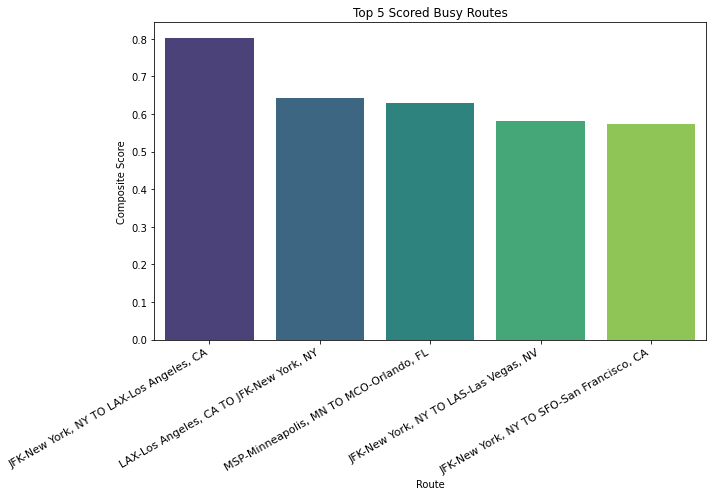

In [125]:
plot_top_scored_routes(combined_df)


## Recommended Routes:
### 1. New York, NY to Los Angeles, CA
### 2. Los Angeles, CA to New York, NY
### 3. Minneapolis, MN to Orlando, FL
### 4. New York, NY to Las Vegas, NV
### 5. New York, NY to San Francisco, CA

# 4.The number of round trip flights it will take to breakeven on the upfront airplane cost for each of the 5 round trip routes that you recommend.

In [126]:
combined_df= combined_df.assign(TRIPS_COUNT_TO_BREAKEVEN = lambda x: ((90000000/x['profit_per_trip'])))

combined_df.assign(TRIPS_COUNT_TO_BREAKEVEN = lambda x: ((90000000/x['profit_per_trip']))).to_excel('Final_Solution.xlsx')

print(combined_df)

     ORIGIN DESTINATION ORIGIN_STATE_NM  ITIN_FARE  PASSENGERS  \
1585    JFK         LAX        New York   833288.0      3580.0   
1399    LAX         JFK      California   670204.0      2265.0   
1739    MSP         MCO       Minnesota   272637.0      2529.0   
1485    JFK         LAS        New York   438812.0      1646.0   
2321    JFK         SFO        New York   778869.0      1803.0   
...     ...         ...             ...        ...         ...   
1065    ASE         DEN        Colorado     2133.0         6.0   
4712    ORD         SDF        Illinois    22685.0        71.0   
3639    BNA         EWR       Tennessee    46934.0       172.0   
2298    BUR         SFO      California    45883.0       512.0   
587     SDF         ORD        Kentucky    19348.0        71.0   

     ORIGIN_CITY_NAME     DEST_CITY_NAME  LOG_AIR_TIME  LOG_DISTANCE  \
1585     New York, NY    Los Angeles, CA  18473.793497  24677.874044   
1399  Los Angeles, CA       New York, NY  17835.434036  24709.1

### Calculating the number of round trip flights required to breakeven on the upfront airplane cost for each of the 5 recommended routes provides critical insight into the investment recovery timeline and financial viability of these routes. Routes with a lower breakeven flight count indicate quicker return on investment, suggesting they are more attractive for scaling or fleet allocation because they can cover the fixed airplane costs faster through operational profits. 

### Conversely, routes requiring more flights to breakeven may still be profitable but demand longer commitment and higher operational capacity before yielding net gains. This analysis helps prioritize routes not just on profitability or operational metrics alone but also on capital efficiency and risk management, guiding strategic decisions about where to invest aircraft and resources to maximize return while balancing operational performance and demand.

In [127]:
print(combined_df.head())

     ORIGIN DESTINATION ORIGIN_STATE_NM  ITIN_FARE  PASSENGERS  \
1585    JFK         LAX        New York   833288.0      3580.0   
1399    LAX         JFK      California   670204.0      2265.0   
1739    MSP         MCO       Minnesota   272637.0      2529.0   
1485    JFK         LAS        New York   438812.0      1646.0   
2321    JFK         SFO        New York   778869.0      1803.0   

     ORIGIN_CITY_NAME     DEST_CITY_NAME  LOG_AIR_TIME  LOG_DISTANCE  \
1585     New York, NY    Los Angeles, CA  18473.793497  24677.874044   
1399  Los Angeles, CA       New York, NY  17835.434036  24709.131642   
1739  Minneapolis, MN        Orlando, FL   3192.059601   4508.126564   
1485     New York, NY      Las Vegas, NV   5016.241713   6722.587869   
2321     New York, NY  San Francisco, CA  10953.060190  14616.352779   

      ARR_DELAY  ...          cost        profit  profit_per_trip busy_route  \
1585     -332.0  ...  6.454829e+07  2.918694e+09     9.242224e+05          1   
1399   -11

In [128]:
print(combined_df[['route', 'TRIPS_COUNT_TO_BREAKEVEN']].head())

                                          route  TRIPS_COUNT_TO_BREAKEVEN
1585    JFK-New York, NY TO LAX-Los Angeles, CA                 97.379162
1399    LAX-Los Angeles, CA TO JFK-New York, NY                195.906609
1739     MSP-Minneapolis, MN TO MCO-Orlando, FL                 83.582812
1485      JFK-New York, NY TO LAS-Las Vegas, NV                111.271211
2321  JFK-New York, NY TO SFO-San Francisco, CA                122.741239


# 5. Key Performance Indicators (KPI’s) that you recommend tracking in the future to measure the success of the round trip routes that you recommend.  

## To measure the ongoing success of the round trip routes we recommend, I suggest tracking KPIs across categories like financial, operational, weather impact, airport congestion, customer and marketing KPI's, etc,


### Here are some KPI's that provides crucial Insights:


### 1. Total Round -Trip Flights per Route: Total operational frequency in a quarter.
### 2. Profit per Round Trip: Measures the net earnings for each complete round trip, reflecting route profitability and pricing efficiency.
### 3.Load Factor: Percentage of available seats filled by passengers, indicating demand and capacity utilization on the route.
### 4.On-Time Performance (Delay Metrics): Tracks average departure and arrival delays to monitor operational efficiency and customer satisfaction.
### 5. Aircraft Utilization Rate: Average number of hours per day each aircraft is in active use.
### 6. Issue Resolution: Customer issues resolved on first interaction.
### 7. Revenue per Passenger: Revenue from baggage, meals, seat selection, upgrade rate, on boarding services, etc
### 8. Weather Disruption Index: number of flights impacted by weather over total flights.
### 9. Airport Load Factors: Indicates pressure or performance at origin/destination airports.
### 10. Seasonal Demand Variance: Fluctuations in occupancy and profitability across quarters.
### 11. On-Time Arrival & Departure Rate: Percentage of flights operating within scheduled time.
### 12. Missed Connection Rate: % of passengers missing connections due to delays.
### 13. Promotions & Pricing: 	% of users exposed to a promotion who booked a flight.
### 14. Market Penetration: Attract new customers or enter new routes.

# Conclusion 



### The analysis of U.S. domestic flight and ticket data for Q1 2019 provides valuable insights for the airline’s market entry strategy. By preprocessing and analyzing key metrics including profitability (derived from fares and occupancy rates), delays, and demand (passenger volume and flight frequency). identified the most promising routes for investment. The methodology involved:

### Data Cleaning & Transformation – Handling missing values, removing duplicates, and applying log transformations to normalize skewed distributions.

### Route Performance Evaluation – Aggregating flight and ticket data to assess profitability, punctuality, and demand at the route level.

### Scoring & Ranking – Developing a weighted scoring system to prioritize routes that balance high revenue, strong demand, and minimal delays.

### Breakeven Consideration – Factoring in the 90M aircraft cost to ensure financial viability.

### The final recommendations highlight the top 5 round-trip routes that align with the airline’s goals of profitability, operational efficiency, and customer satisfaction. These selections are based on objective data rather than intuition, ensuring a competitive advantage in the U.S. domestic market.


# Improvements - Strategic next steps

### 1. Financial Performance & Profitability Optimization
#### Cost Modeling: Integrate operational costs (fuel, crew, maintenance, airport fees) to calculate net profitability per route.
#### Breakeven Refinement: Adjust the 90M aircraft breakeven threshold by factoring in variable costs (e.g., shorter routes may have lower costs but also lower fares).
#### ROI Projections: Compare high-revenue routes against capital expenditure to prioritize those with the fastest payback periods.

### 2. Operational Efficiency & Fleet Utilization
#### Aircraft Assignment: Optimize aircraft type (e.g., regional jets vs. wide-bodies) based on route demand and airport constraints.
#### Turnaround Time Analysis: Minimize ground time at hubs to maximize daily flight rotations.
#### Fuel Efficiency: Prioritize routes with favorable wind patterns and shorter taxi times to reduce fuel burn.

### 3. Dynamic Pricing & Revenue Management
#### Demand-Based Pricing: Adjust fares in real-time using historical booking patterns, competitor pricing, and seasonal trends.
#### Ancillary Revenue: Monetize premium seating, baggage fees, and partnerships on high-demand routes.
#### Overbooking Strategy: Use predictive analytics to optimize seat overbooking without compromising customer satisfaction.

### 4. Flight Delay & Disruption Management
#### Predictive Delay Modeling: Identify routes with historically high delays and implement mitigation strategies (e.g., buffer times, alternate flight paths).
#### Operational Contingencies: Develop rapid rebooking protocols for disrupted flights to minimize passenger inconvenience.
#### Airport-Specific Insights: Partner with high-traffic airports (e.g., JFK, LAX) to secure preferential gate access and reduce congestion-related delays.

### 5. Demand Forecasting & Seasonal Adjustments
#### Historical Trend Analysis: Expand beyond Q1 data to capture seasonal peaks (holidays, summer travel).
#### Machine Learning Models: Predict future demand using economic indicators, events, and booking trends.
#### Flexible Scheduling: Allocate additional capacity to high-growth routes while scaling back underperforming ones.

### By executing these steps, the airline can transition to a operational success, ensuring a profitable, punctual, and scalable U.S. domestic network. The focus should remain on data agility continuously refining routes based on real-world performance.